# Graphite voltage: bulk and interface OCV

Compare terminal voltage with OCV evaluated at bulk-average lithiation and the **AvP-weighted average of local interface OCV**. The interface curve is a nodal diagnostic, not an exact equilibrium or terminal-voltage prediction. It averages `U(c)` rather than evaluating `U` at averaged interface concentration.

Run all cells. Paths work from the repository root or `plotting/`. The results folder and `dh` are read from the log unless overridden. Only timesteps present in both the log and saved `CnP` snapshots are compared. The interface threshold matches `Reaction.cpp`: `AvP * dh > 1e-3`.


In [1]:
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "src/battery_simulation.cpp").is_file())
log_file = repo_root / "bin/graphite_test.txt"
result_dir_override = None  # Example: repo_root / "outputs/Results/20261007_191940"
dh_override = None
ocv_file = repo_root / "inputs/materials/Graphite/ocv.txt"
snapshot_stride = 1  # Use every Nth matching saved snapshot.
interface_threshold = 1e-3
output_dir = repo_root / "plotting/graphite_interface_comparison"


In [2]:
import re
import numpy as np
import pandas as pd
import mfem.ser as mfem
import matplotlib.pyplot as plt

number = r"[-+]?(?:\d*\.\d+|\d+\.?\d*)(?:[eE][-+]?\d+)?"
text = log_file.read_text()
rows = []
# Bound each status record at the next timestep, avoiding partial-record mixing.
for block in re.split(r"(?=^timestep:)", text, flags=re.M):
    header = re.match(r"timestep:\s*(\d+)\s*\[ANODE HALF-CELL\]", block)
    if header is None:
        continue
    voltage = re.search(r"\bVCell\s*=\s*(" + number + ")", block)
    bulk = re.search(r"\bXfrA_avg\s*=\s*(" + number + ")", block)
    if voltage and bulk:
        rows.append((int(header[1]), float(bulk[1]), float(voltage[1])))
if not rows:
    raise ValueError(f"No complete anode status records in {log_file}")
data = pd.DataFrame(rows, columns=["timestep", "bulk_lithiation", "cell_voltage"])
data = data.drop_duplicates("timestep", keep="last").sort_values("timestep")

if result_dir_override is None:
    match = re.search(r"^output_dir\s*=\s*(.+)$", text, re.M)
    if match is None:
        raise ValueError("Set result_dir_override: no output_dir found in the log.")
    result_dir = Path(match[1].strip())
    if not result_dir.is_absolute():
        result_dir = (log_file.parent / result_dir).resolve()
else:
    result_dir = Path(result_dir_override)
if dh_override is None:
    match = re.search(r"^dh\s*=\s*(" + number + ")", text, re.M)
    if match is None:
        raise ValueError("Set dh_override: no dh found in the log.")
    dh = float(match[1])
else:
    dh = float(dh_override)
if not np.isfinite(dh) or dh <= 0:
    raise ValueError("dh must be finite and positive.")
if not isinstance(snapshot_stride, int) or snapshot_stride < 1:
    raise ValueError("snapshot_stride must be a positive integer.")

snapshots = {int(p.stem.rsplit("_", 1)[-1]): p for p in result_dir.glob("CnP_[0-9]*")
             if p.stem.rsplit("_", 1)[-1].isdigit()}
skipped = len(data) - data.timestep.isin(snapshots).sum()
data = data[data.timestep.isin(snapshots)].iloc[::snapshot_stride].copy().reset_index(drop=True)
if data.empty:
    raise ValueError(f"No matching CnP snapshots in {result_dir}")

table = np.loadtxt(ocv_file)
if table.ndim != 2 or table.shape[1] != 2 or not np.isfinite(table).all():
    raise ValueError("OCV table must contain finite concentration/value pairs.")
table = table[np.argsort(table[:, 0])]
if np.any(np.diff(table[:, 0]) <= 0):
    raise ValueError("OCV concentrations must be unique.")
mesh = mfem.Mesh(str(result_dir / "pmesh"), 1, 1)
def load_scalar(path):
    field = mfem.GridFunction(mesh, str(path))
    if field.FESpace().GetVDim() != 1:
        raise ValueError(f"Expected scalar field: {path}")
    values = np.array(field.GetDataArray(), copy=True)
    if not np.isfinite(values).all():
        raise ValueError(f"Non-finite values in {path}")
    return values

avp = load_scalar(result_dir / "AvP")
interface = avp * dh > interface_threshold
if not interface.any():
    raise ValueError("No nodes meet the interface threshold.")
weights = avp[interface]
interface_ocv, interface_c = [], []
for step in data.timestep:
    c = load_scalar(snapshots[step])
    if c.shape != avp.shape:
        raise ValueError(f"CnP and AvP sizes differ at timestep {step}")
    local_ocv = np.interp(c[interface], table[:, 0], table[:, 1])
    interface_ocv.append(np.average(local_ocv, weights=weights))
    interface_c.append(np.average(c[interface], weights=weights))
data["bulk_ocv"] = np.interp(data.bulk_lithiation, table[:, 0], table[:, 1])
data["interface_ocv"] = interface_ocv
data["interface_lithiation"] = interface_c
data["voltage_minus_bulk_ocv_mV"] = 1000 * (data.cell_voltage - data.bulk_ocv)
data["voltage_minus_interface_ocv_mV"] = 1000 * (data.cell_voltage - data.interface_ocv)
print(f"Results: {result_dir}\nCompared {len(data)} snapshots; {skipped} logged timesteps lacked snapshots.")
display(data.tail())


Results: /mnt/ffs24/home/brandlan/BESFEM/outputs/Results/20261007_191940
Compared 135 snapshots; 0 logged timesteps lacked snapshots.


,timestep,bulk_lithiation,cell_voltage,bulk_ocv,interface_ocv,interface_lithiation,voltage_minus_bulk_ocv_mV,voltage_minus_interface_ocv_mV
130,1300000,0.128199,0.142976,0.197648,0.145485,0.221386,-54.672008,-2.509169
131,1310000,0.128880,0.142546,0.196798,0.145081,0.223033,-54.251984,-2.535416
132,1320000,0.129558,0.142163,0.195952,0.144694,0.224675,-53.788704,-2.530934
133,1330000,0.130233,0.141780,0.195183,0.144318,0.226306,-53.403310,-2.538387
134,1340000,0.130906,0.141445,0.194557,0.143952,0.227923,-53.112420,-2.507032


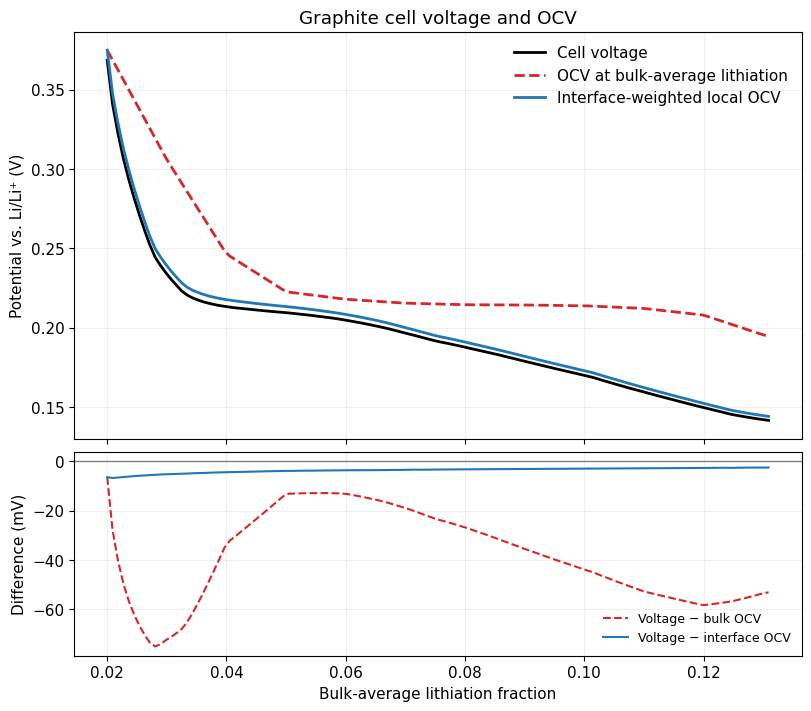

Saved figure: /mnt/ffs24/home/brandlan/BESFEM/plotting/graphite_interface_comparison/graphite_bulk_interface_ocv.png


In [3]:
output_dir.mkdir(parents=True, exist_ok=True)
with plt.rc_context({"font.size": 11}):
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, layout="constrained",
                             gridspec_kw={"height_ratios": [2, 1]})
    x = data.bulk_lithiation
    axes[0].plot(x, data.cell_voltage, color="black", lw=2, label="Cell voltage")
    axes[0].plot(x, data.bulk_ocv, "--", color="tab:red", lw=2,
                 label="OCV at bulk-average lithiation")
    axes[0].plot(x, data.interface_ocv, color="tab:blue", lw=2,
                 label="Interface-weighted local OCV")
    axes[0].set(ylabel="Potential vs. Li/Li⁺ (V)", title="Graphite cell voltage and OCV")
    axes[0].legend(frameon=False)
    axes[1].axhline(0, color="0.5", lw=1)
    axes[1].plot(x, data.voltage_minus_bulk_ocv_mV, "--", color="tab:red", label="Voltage − bulk OCV")
    axes[1].plot(x, data.voltage_minus_interface_ocv_mV, color="tab:blue", label="Voltage − interface OCV")
    axes[1].set(xlabel="Bulk-average lithiation fraction", ylabel="Difference (mV)")
    axes[1].legend(frameon=False, fontsize=9)
    for ax in axes:
        ax.grid(alpha=0.2)
    figure_path = output_dir / "graphite_bulk_interface_ocv.png"
    fig.savefig(figure_path, dpi=200)
    plt.show()
data.to_csv(output_dir / "graphite_bulk_interface_ocv.csv", index=False)
print(f"Saved figure: {figure_path}")
